In [31]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/salary-dataset-simple-linear-regression/Salary_dataset.csv


In [32]:
import numpy as np
import pandas as pd

In [33]:
df = pd.read_csv('/kaggle/input/salary-dataset-simple-linear-regression/Salary_dataset.csv')
df = df.drop(df.columns[0],axis=1)
df

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0
5,3.0,56643.0
6,3.1,60151.0
7,3.3,54446.0
8,3.3,64446.0
9,3.8,57190.0


<Axes: xlabel='YearsExperience', ylabel='Salary'>

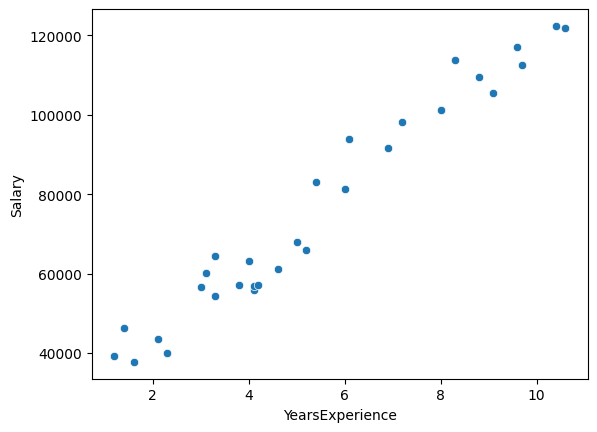

In [34]:
import seaborn as sns
sns.scatterplot(data = df, x = 'YearsExperience', y = 'Salary')

In [35]:
x = df.iloc[:,0:1]
x

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3
5,3.0
6,3.1
7,3.3
8,3.3
9,3.8


In [36]:
y = df.iloc[:,-1]
y

0      39344.0
1      46206.0
2      37732.0
3      43526.0
4      39892.0
5      56643.0
6      60151.0
7      54446.0
8      64446.0
9      57190.0
10     63219.0
11     55795.0
12     56958.0
13     57082.0
14     61112.0
15     67939.0
16     66030.0
17     83089.0
18     81364.0
19     93941.0
20     91739.0
21     98274.0
22    101303.0
23    113813.0
24    109432.0
25    105583.0
26    116970.0
27    112636.0
28    122392.0
29    121873.0
Name: Salary, dtype: float64

In [37]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 2)

In [38]:
x_test

,YearsExperience
1,1.4
0,1.2
14,4.6
9,3.8
21,7.2
19,6.1


In [39]:
y_test

1     46206.0
0     39344.0
14    61112.0
9     57190.0
21    98274.0
19    93941.0
Name: Salary, dtype: float64

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
model = LinearRegression()

In [42]:
model.fit(x_train,y_train)

LinearRegression()

In [43]:
model.predict(x_test)

array([36834.63210301, 34920.71472592, 67457.3101364 , 59801.64062805,
       92338.23603852, 81811.69046455])

In [44]:
model.predict(x_test.iloc[0].values.reshape(1,1))

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([36834.63210301])

<Axes: xlabel='YearsExperience', ylabel='Salary'>

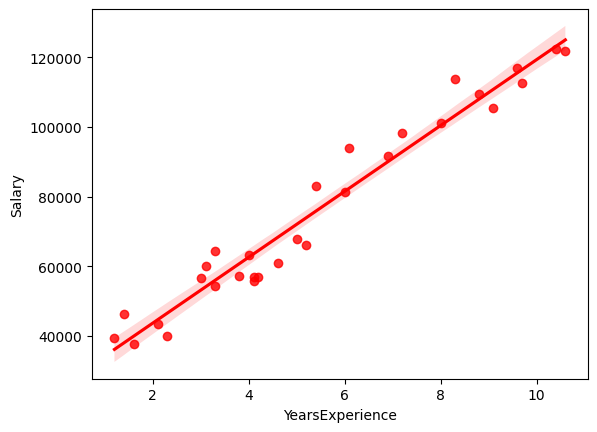

In [45]:
sns.regplot(x = df['YearsExperience'], y = df['Salary'],color = 'red')

Text(0, 0.5, 'Salary')

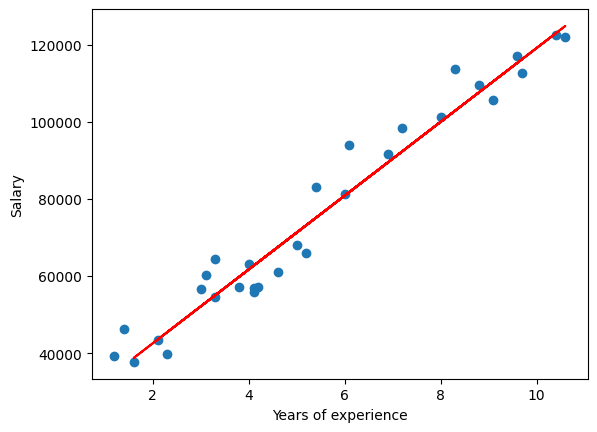

In [46]:
import matplotlib.pyplot  as plt
plt.scatter(df['YearsExperience'],df['Salary'])
plt.plot(x_train,model.predict(x_train),color = 'red')
plt.xlabel('Years of experience')
plt.ylabel('Salary')

In [47]:
m = model.coef_
b = model.intercept_
print('m = ',m,'b =',b)

m =  [9569.58688543] b = 23437.21046340505


In [48]:
x_train = x_train.values
y_train = y_train.values

# Custom simple linear Regression
**This is basically internal working of sklearn's linearRegression model**

In [49]:
class customLR():
    def __init__(self):
       self.m = None
       self.b = None

    def fit(self, x_train, y_train):
        numerator = 0
        denomenator = 0
        for i in range(x_train.shape[0]):
            numerator = numerator + ((x_train[i] - x_train.mean())*(y_train[i] - y_train.mean()))
            denomenator = denomenator + ((x_train[i] - x_train.mean())**2)
        self.m = numerator/denomenator

        self.b = y_train.mean() - (self.m * x_train.mean())
        print(self.m)
        print(self.b)

    def predict(self,x_test):
        return self.m*x_test + self.b
        

In [ ]:
lr = customLR()

In [ ]:
lr.fit(x_train,y_train)

[9569.58688543]
[23437.21046341]


In [ ]:
y_pred = np.array(lr.predict(x_test))
y_actual = np.array(y_test)
residuals = y_pred - y_actual
residuals

array([[ -9371.36789699,  -2509.36789699, -24277.36789699,
        -20355.36789699, -61439.36789699, -57106.36789699],
       [-11285.28527408,  -4423.28527408, -26191.28527408,
        -22269.28527408, -63353.28527408, -59020.28527408],
       [ 21251.3101364 ,  28113.3101364 ,   6345.3101364 ,
         10267.3101364 , -30816.6898636 , -26483.6898636 ],
       [ 13595.64062805,  20457.64062805,  -1310.35937195,
          2611.64062805, -38472.35937195, -34139.35937195],
       [ 46132.23603852,  52994.23603852,  31226.23603852,
         35148.23603852,  -5935.76396148,  -1602.76396148],
       [ 35605.69046455,  42467.69046455,  20699.69046455,
         24621.69046455, -16462.30953545, -12129.30953545]])

<Axes: >

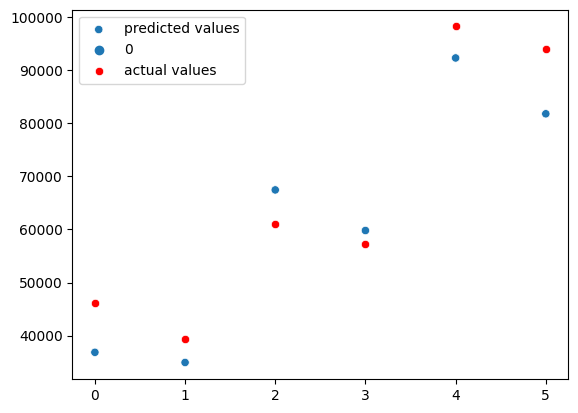

In [ ]:
sns.scatterplot(y_pred, color = 'blue',label = 'predicted values')
sns.scatterplot(y_actual,color = 'red',label = 'actual values')

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
print('MAE = ',mean_absolute_error(y_actual,y_pred))

MAE =  6802.779572073905


In [ ]:
print('MSE =',mean_squared_error(y_actual,y_pred))

MSE = 56137509.99782566


In [ ]:
print('RMSE =',np.sqrt(mean_squared_error(y_actual,y_pred)))

RMSE = 7492.49691343451


In [ ]:
print('r2 score = ',r2_score(y_actual,y_pred))
r2 = r2_score(y_actual,y_pred)

r2 score =  0.8886956733784561


In [ ]:
adjusted_r2_score = 1-((r2)*(1-6)/(1-6-1))
adjusted_r2_score

0.2594202721846198